<a href="https://colab.research.google.com/github/htastan/Machine-Learning-in-Economics/blob/main/ANN_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Neural Networks

This notebook partly replicates and extends the example we saw in class:  
[Lab 12: Deep Learning — Simulated Data Example](https://htastan.github.io/Machine-Learning-in-Economics/Labs/Lab-12-Deep-learning.html#12_Example:_Simulated_data)

In this notebook, we will use **Python (TensorFlow/Keras)** to:

- Simulate a dataset,
- Build and train a **feedforward neural network**,
- Monitor training and **validation performance** over epochs,
- Visualize the **mean squared error (MSE)** across epochs,
- Discuss the role of hyperparameters such as **learning rate**, **batch size**, **epochs**, and **activation functions**.

Our goal is to understand how neural networks learn from data, and how to monitor their generalization performance using a validation set — without peeking at the test set during training.

This hands-on example complements the concepts introduced in class and gives you a foundation for using ANNs in real-world problems.

## Setup the environment and simulated data

In [1]:
# Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import networkx as nx

The code block above sets up the environment by bringing in all the necessary tools (libraries and specific functions/classes) needed to simulate data, build and train machine learning models (both linear regression and neural networks), evaluate their performance, and visualize results.

In [2]:
np.random.seed(1)
tf.random.set_seed(1)

# Simulate data
n = 1000
x1 = np.random.randn(n)
x2 = np.random.randn(n)
x3 = np.random.randn(n)

y = (10 + 2*x1 - 5*x2 + 4*x3 + 3*x1*x2 - 8*x1*x3 + 2*x2*x3 + 5*x1*x2*x3 + np.random.randn(n))

df = pd.DataFrame({'x1':x1, 'x2':x2, 'x3':x3, 'y':y})


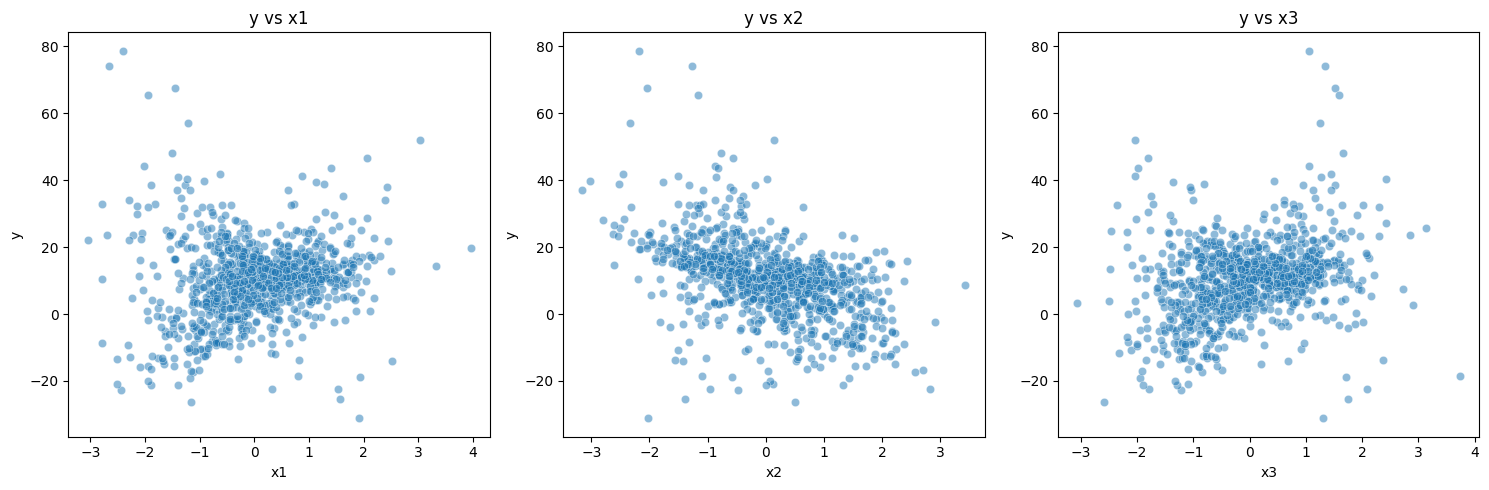

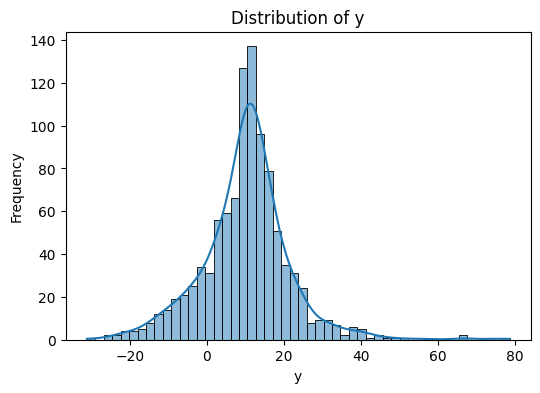

In [3]:
# Visualize the data

import seaborn as sns

# Scatter plots of features vs target
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='x1', y='y', data=df, alpha=0.5)
plt.title('y vs x1')

plt.subplot(1, 3, 2)
sns.scatterplot(x='x2', y='y', data=df, alpha=0.5)
plt.title('y vs x2')

plt.subplot(1, 3, 3)
sns.scatterplot(x='x3', y='y', data=df, alpha=0.5)
plt.title('y vs x3')

plt.tight_layout()
plt.show()

# Histogram of the target variable
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='y', kde=True)
plt.title('Distribution of y')
plt.xlabel('y')
plt.ylabel('Frequency')
plt.show()


The figure above shows scatter plots of the response variable `y` against each of the input features `x1`, `x2`, and `x3` in the simulated dataset.

- The relationship between the features and the output appears **nonlinear and noisy**.
- There is no strong **linear correlation**, suggesting that a simple linear regression may not capture the underlying pattern well.
- This makes the data a suitable candidate for a **nonlinear model**, such as an artificial neural network (ANN), to learn the hidden structure.

## Train-test split

In [62]:
#
# Train-test split
train, test = train_test_split(df,
                               test_size = 0.25,
                               random_state = 42)
X_train = train[['x1','x2','x3']].values
y_train = train['y'].values
X_test = test[['x1','x2','x3']].values
y_test = test['y'].values

## Linear Regression without interactions and a Simple ANN

We fit a linear regression model without interaction terms using OLS first. Then we fit a simple ANN with a single unit using identity (linear) activation.

In [63]:
# Fit Linear Regression (analogy to ANN with no hidden layer)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lin = linreg.predict(X_test)
mse_lin = mean_squared_error(y_test, y_pred_lin)
print(f"Linear Regression Test MSE: {mse_lin:.4f}")

Linear Regression Test MSE: 81.2383


The test MSE from the linear regression model is 81.2383.

In [64]:
# Fit ANN (no hidden layer, linear output neuron)
# This ANN is practically the same as a linear regression
#
# Setup the model tensorflow.keras
model = Sequential([
    Dense(1,                   # layer has 1 neuron (unit)
          activation='linear', # activation function (identity)
          input_shape=(3,))    # single output neuron with 3 inputs
    ])

# Model compilation: configure the model for training
model.compile(optimizer =
              tf.keras.optimizers.SGD( # Stochastic Gradient Descent options
                              learning_rate =0.05
                                     ),
              loss = 'mse' # evaluation criterion MSE
              )

# Training
history = model.fit(
    X_train,                # 🧠 Input features (training data)
    y_train,                # 🎯 Target values
    epochs = 100,           # 🔁 Number of full passes over the training data
    batch_size = 64,        # 📦 Number of samples used before updating weights
    validation_split = 0.2, # 🔍 Hold out 20% of training data for validation (used to monitor generalization)
    shuffle = True,         # 🔄 Randomly shuffle training data at each epoch (suitable for i.i.d. data)
    verbose = 1             # 📣 Verbosity mode: 0 = silent, 1 = progress bar, 2 = one line per epoch
)
# continue training with additional epochs
# model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 197.9720 - val_loss: 111.5283
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 106.1507 - val_loss: 90.3277
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 94.5879 - val_loss: 86.5143
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 93.1100 - val_loss: 85.6207
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.9143 - val_loss: 85.3596
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 92.8863 - val_loss: 85.2734
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.8817 - val_loss: 85.2434
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.8808 - val_loss: 85.2328
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.8807 - val_loss: 85.2290
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.8806 - val_loss: 85.2276
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.8806 - val_loss: 85.2271
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms

### Detailed Explanation of Training Options

When training a neural network with Keras using `model.fit()`, several options control how the training process is performed. Here's a breakdown of each option used in the code:

- **`X_train, y_train`**:  
  The training features and corresponding target values. These are the data the model uses to learn the underlying function.

- **`epochs`**:  
  The number of times the entire training dataset is passed through the model.  
  **Example:** `epochs=100` means the model will make 100 complete passes over the training data.  
  *Note:* More epochs generally allow the model to learn more, but too many can lead to overfitting.

- **`batch_size`**:  
  The number of samples processed before the model’s internal parameters (weights) are updated.  
  **Example:** `batch_size=50` means the training data is split into batches of 50.  
  *Why it matters:*  
  - A smaller batch size can provide a more fine-grained update but can be noisier and slower per epoch.  
  - A larger batch size can speed up training but may risk missing some variability present in the data.

- **`validation_split`**:  
  The fraction of the training data to be held out as a validation set, which is not used for training but to evaluate the model’s performance during training.  
  **Example:** `validation_split=0.2` means 20% of the training data is used for validation.  
  *Why it matters:*  
  - The validation set is used to monitor for overfitting; if performance on the validation data stops improving, you might consider stopping training or adjusting hyperparameters.

- **`shuffle`**:  
  Determines whether the training data is reshuffled at the beginning of each epoch.  
  **Example:** `shuffle=True` implies that the data is randomly rearranged before each pass through the model.  
  *Important:*  
  - **For i.i.d. data:** Shuffling helps ensure that batches are representative of the overall data distribution, leading to smoother and more stable training.
  - **For time series or sequential data:** Shuffling should typically be set to `False` to preserve the temporal order, because the sequence in which data points occur is important.

- **`verbose`**:  
  Controls the verbosity of the training output.  
  **Example:** `verbose=1` will display a progress bar with real-time updates on epoch progress and loss values.  
  *Other options:*  
  - `verbose=0` for no output,  
  - `verbose=2` for a more compact, epoch-level summary.

---

By explicitly setting these options, you see how each parameter shapes the training process:
- **Epochs** and **batch size** influence how many updates occur.
- **Validation split** ensures that you can monitor the model's generalization on unseen data during training.
- **Shuffle** guarantees randomness for i.i.d. data but needs to be turned off when data order is crucial.
- **Verbose** gives you insight into the training progress.

This detailed setup lets you experiment with different configurations and observe their effects on the learning behavior — an excellent hands-on approach to understanding deep learning training dynamics.


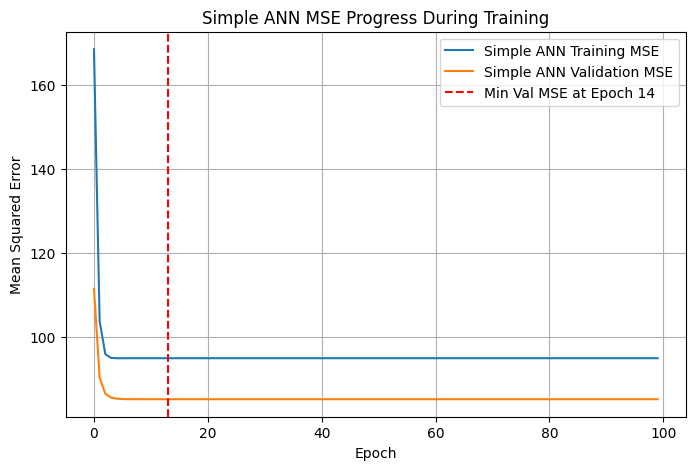

In [65]:
# Plot training & validation loss for Simple ANN

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Simple ANN Training MSE')
plt.plot(history.history['val_loss'], label='Simple ANN Validation MSE') # 'val_loss' is available now

# Find the epoch with the minimum validation MSE (optional for simple linear models)
min_val_mse_simple = min(history.history['val_loss'])
best_epoch_simple_index = history.history['val_loss'].index(min_val_mse_simple)
best_epoch_simple = best_epoch_simple_index + 1
plt.axvline(x=best_epoch_simple_index, color='r', linestyle='--', label=f'Min Val MSE at Epoch {best_epoch_simple}')

plt.title('Simple ANN MSE Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


In [66]:
# compute out of sample predictions and test MSE
y_pred_ann = model.predict(X_test).flatten() # flatten() converts output into a vector
mse_ann = mean_squared_error(y_test, y_pred_ann) # compute MSE using sklearn.metrics
print(f"Simple ANN Test MSE: {mse_ann:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Simple ANN Test MSE: 81.1230


This simple ANN (equivalent to a linear regression, because it has no hidden layers and uses a linear output activation) has a test MSE of 81.12. (Note: Due to the iterative training process, the exact number can vary slightly when you run it, but should be very close). This result is practically the same as the linear regression test MSE found previously, 81.23. The minor difference is expected because ANNs use gradient descent for optimization, which is an iterative approximation method, unlike the direct calculation methods used by linear regression.

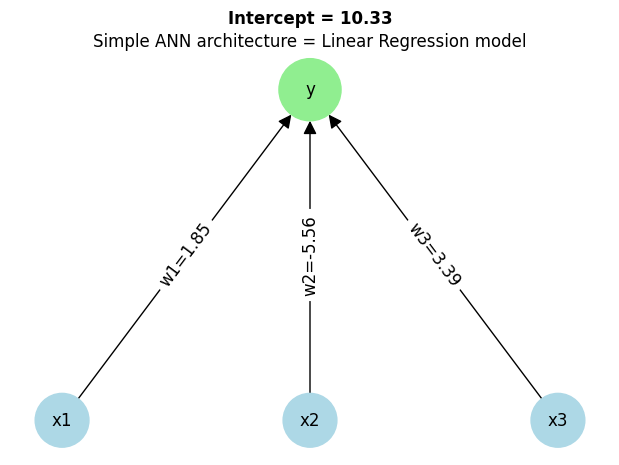

In [67]:
# Visualizing the simple ANN / Linear Regression architecture

def plot_simple_ann():
    G = nx.DiGraph()

    # Nodes: Input features
    input_nodes = ['x1', 'x2', 'x3']
    output_node = 'y'

    # Add nodes
    for node in input_nodes:
        G.add_node(node, color='lightblue', size=1500)
    G.add_node(output_node, color='lightgreen', size=2000)

    # Add edges with weights (use linear regression coefficients)
    coefs = linreg.coef_
    intercept = linreg.intercept_

    edge_labels = {}
    for i, node in enumerate(input_nodes):
        G.add_edge(node, output_node)
        edge_labels[(node, output_node)] = f'w{i+1}={coefs[i]:.2f}'

    # Draw graph
    pos = { 'x1': (-1,0), 'x2': (0,0), 'x3': (1,0), 'y': (0,1)}
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]
    node_sizes = [G.nodes[n]['size'] for n in G.nodes()]

    plt.figure(figsize=(6,4))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, arrowsize=20)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)
    # Display intercept as text
    plt.text(0,1.2,f'Intercept = {intercept:.2f}', horizontalalignment='center', fontsize=12, fontweight='bold')
    plt.title("Simple ANN architecture = Linear Regression model")
    plt.axis('off')
    plt.show()

plot_simple_ann()

In [68]:
print("Linear Regression coefficients:", linreg.coef_)
print("Linear Regression intercept:", linreg.intercept_)

weights, biases = model.layers[0].get_weights()
print("ANN weights:", weights.flatten())
print("ANN bias:", biases)

Linear Regression coefficients: [ 1.85086544 -5.56052339  3.3871578 ]
Linear Regression intercept: 10.33055681192684
ANN weights: [ 2.3381398 -5.24539    3.267968 ]
ANN bias: [10.391029]


The perceptron-style ANN with no hidden layers and linear output (identity activation) is mathematically equivalent to linear regression. The only difference is that ANN training typically uses iterative optimization, so convergence and parameter accuracy depend on training settings.

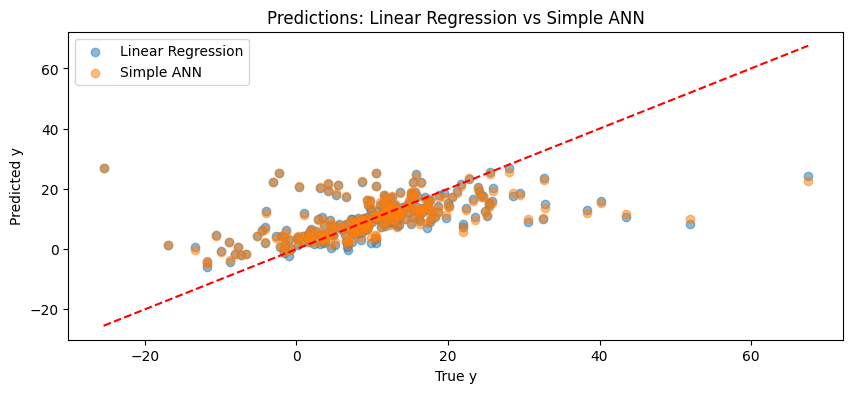

Linear Regression Test R-squared: 0.2861
Simple ANN Test R-squared: 0.2871


In [69]:
from sklearn.metrics import r2_score

# Plot predictions comparison

plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred_lin, alpha=0.5, label='Linear Regression')
plt.scatter(y_test, y_pred_ann, alpha=0.5, label='Simple ANN')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions: Linear Regression vs Simple ANN')
plt.legend()
plt.show()

# Calculate and print R-squared for Linear Regression
r2_lin = r2_score(y_test, y_pred_lin)
print(f"Linear Regression Test R-squared: {r2_lin:.4f}")

# Calculate and print R-squared for Simple ANN
r2_ann = r2_score(y_test, y_pred_ann)
print(f"Simple ANN Test R-squared: {r2_ann:.4f}")

Both methods produced an R2 = 0.29, not a good prediction performance. As can be seed from the scatterplot of actual and predicted values, there are large errors in the linear model (points far from the diagonal line).

To improve the model's performance and capture the complex relationship in the data, we need to use a model that can learn potential non-linear interactions. This is where the power of more complex Artificial Neural Networks (ANNs) with hidden layers and non-linear activation functions comes into play. These architectures can learn to represent and utilize these interaction terms implicitly through their network structure and learned weights.

## A More Complex network: ANN(3,3) two hidden layers with 3 units each

In [70]:
# Scale the data first
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# train/test split
train, test = train_test_split(df_scaled,
                               test_size = 0.25,
                               random_state = 555)
X_train = train[['x1', 'x2', 'x3']].values
y_train = train['y'].values
X_test = test[['x1', 'x2', 'x3']].values
y_test = test['y'].values

In [88]:
# Build and train the ANN with two hidden layers (3 neurons each)
# ANN(3,3)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# build the model
model = Sequential([
    Dense(3, activation='tanh', input_shape=(3,)),
    Dense(3, activation='tanh'),
    Dense(1, activation='linear')
])
# use Adam optimizer with a small learning rate
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse')
history2 = model.fit(X_train,
                     y_train,
                     epochs = 2000,
                     batch_size = 64,
                     validation_split = 0.2, # keep validation MSE data
                     verbose = 1
                     )

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0356 - val_loss: 0.0237
Epoch 2/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0209 - val_loss: 0.0148
Epoch 3/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0133 - val_loss: 0.0115
Epoch 4/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107 - val_loss: 0.0109
Epoch 5/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0103 - val_loss: 0.0106
Epoch 6/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0100 - val_loss: 0.0103
Epoch 7/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0098 - val_loss: 0.0101
Epoch 8/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - val_loss: 0.0099
Epoch 9/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0094 - val_loss: 0.0097
Epoch 10/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0093 - val_loss: 0.0095
Epoch 11/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0094
Epoch 12/2000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s

### Visualize ANN(3,3) network structure

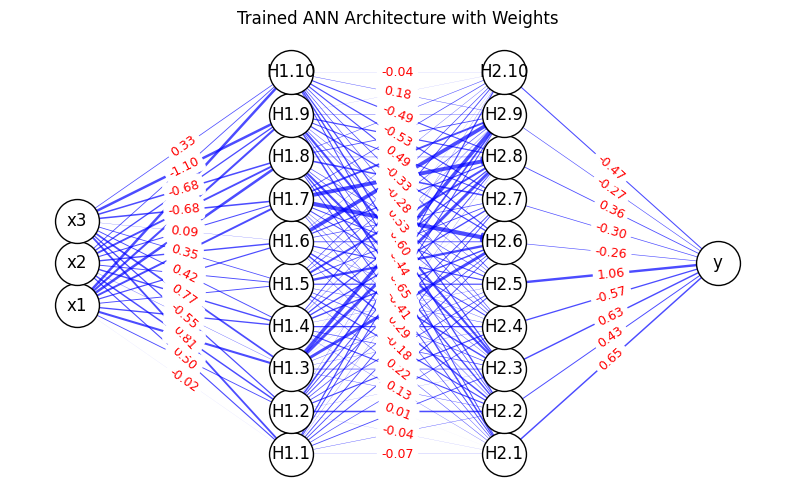

In [103]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_nn(model, feature_names):
    G = nx.DiGraph()

    # Get weights from each layer
    weights = [layer.get_weights()[0] for layer in model.layers]
    biases = [layer.get_weights()[1] for layer in model.layers]

    # Layer sizes
    layers = [len(feature_names)] + [w.shape[1] for w in weights]  # e.g. [3,3,3,1]

    # Positions for nodes (layered horizontally)
    pos = {}
    horiz_gap = 2
    vert_gap = 1
    for i, layer_size in enumerate(layers):
        x = i * horiz_gap
        for j in range(layer_size):
            y = j - (layer_size - 1) / 2
            pos[(i,j)] = (x, y)
            G.add_node((i,j))

    # Add edges with weights as labels
    edge_labels = {}
    for i, W in enumerate(weights):
        for src in range(W.shape[0]):
            for tgt in range(W.shape[1]):
                weight = W[src, tgt]
                G.add_edge((i, src), (i+1, tgt), weight=weight)
                edge_labels[((i, src), (i+1, tgt))] = f"{weight:.2f}"

    # Draw nodes
    plt.figure(figsize=(10,6))
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='white', edgecolors='black')

    # Node labels: feature names for input, numbers for others
    labels = {}
    # input layer
    for i, name in enumerate(feature_names):
        labels[(0,i)] = name
    # hidden + output layers numbered
    for layer_idx in range(1, len(layers)):
        for neuron_idx in range(layers[layer_idx]):
            if layer_idx == len(layers)-1:
                labels[(layer_idx, neuron_idx)] = "y"
            else:
                labels[(layer_idx, neuron_idx)] = f"H{layer_idx}.{neuron_idx+1}"

    nx.draw_networkx_labels(G, pos, labels, font_size=12)

    # Draw edges
    edges = G.edges()
    weights_all = [abs(G[u][v]['weight']) for u,v in edges]
    # Normalize edge widths for visibility
    max_w = max(weights_all)
    widths = [3 * (w / max_w) for w in weights_all]
    nx.draw_networkx_edges(G, pos, edge_color='blue', width=widths, alpha=0.7)

    # Draw edge labels (weights)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)

    plt.axis('off')
    plt.title("Trained ANN Architecture with Weights")
    plt.show()

# Call function with your model and features
plot_nn(model, ['x1', 'x2', 'x3'])

### A note on the activation functions

In the code above, I used `tanh()` as the activation.
You may experiment with alternative activation functions.

| Feature / Property      | `ReLU`                                           | `tanh`                                         | `sigmoid`                                                  |
| ----------------------- | ------------------------------------------------ | ---------------------------------------------- | ---------------------------------------------------------- |
| **Formula**             | $\max(0, x)$                                     | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $\sigma(x) = \frac{1}{1 + e^{-x}}$                         |
| **Range**               | $[0, \infty)$                                    | $[-1, 1]$                                      | $[0, 1]$                                                   |
| **Zero-centered**       | ❌ No                                             | ✅ Yes                                          | ❌ No                                                       |
| **Derivative**          | 1 (if $x > 0$), 0 otherwise                      | $1 - \tanh^2(x)$                               | $\sigma(x)(1 - \sigma(x))$                                 |
| **Vanishing Gradient?** | ❌ No (but can "die")                             | ⚠️ Yes (at extremes)                           | ⚠️ Yes (more severe)                                       |
| **Sparsity (zeros)?**   | ✅ Yes                                            | ❌ No                                           | ❌ No                                                       |
| **Best used when**      | Inputs are positive, sparse activations are okay | Inputs are standardized, symmetry matters      | Binary classification output, less common in hidden layers |
| **Typical use**         | Hidden layers in deep nets                       | Hidden layers when inputs \~ standard normal   | Output layer for probabilities                             |


### Plotting the validation MSE

`history2.history['loss']` (training MSE) and `history2.history['val_loss']` (validation MSE), so that we can plot the progress.

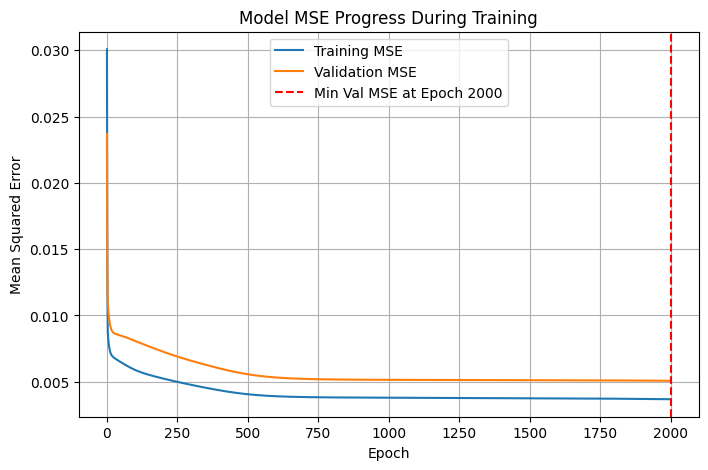

Minimum Validation MSE: 0.005069 occurred at epoch 2000


In [89]:
# Plot training & validation loss curves

plt.figure(figsize=(8, 5))
plt.plot(history2.history['loss'], label='Training MSE')
plt.plot(history2.history['val_loss'], label='Validation MSE') # 'val_loss' contains the validation loss

# Find the epoch with the minimum validation MSE
# Assuming history2 object contains 'val_loss' from training with validation_data
min_val_mse = min(history2.history['val_loss'])
best_epoch_index = history2.history['val_loss'].index(min_val_mse)
best_epoch = best_epoch_index + 1 # +1 because epochs are 1-indexed

# Add a vertical dashed line at the best epoch
plt.axvline(x=best_epoch_index, color='r', linestyle='--', label=f'Min Val MSE at Epoch {best_epoch}') # Use index for plotting

plt.title('Model MSE Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True) # Add a grid for better readability
plt.show()

print(f"Minimum Validation MSE: {min_val_mse:.6f} occurred at epoch {best_epoch}")

In [91]:
# ANN(3, 3) predictions and MSE on the test set
from sklearn.metrics import mean_squared_error

y_pred_nn2 = model.predict(X_test).flatten()
mse_nn2 = mean_squared_error(y_test, y_pred_nn2)
print(f"ANN (2 hidden layers x 3 neurons) Test MSE: {mse_nn2:.6f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
ANN (2 hidden layers x 3 neurons) Test MSE: 0.004306


## ANN(10,10): Two hidden layers with 10 units each

In [94]:
# Fit a denser ANN
# ANN(10, 10)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# build the model
model = Sequential([
    Dense(10, activation='tanh', input_shape=(3,)),
    Dense(10, activation='tanh'),
    Dense(1, activation='linear')
])
# use Adam optimizer with a small learning rate
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='mse')
history3 = model.fit(X_train,
                     y_train,
                     epochs = 500,
                     batch_size = 32,
                     validation_split = 0.2, # keep validation MSE data
                     verbose = 1
                     )

Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0486 - val_loss: 0.0243
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0222 - val_loss: 0.0202
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0195 - val_loss: 0.0178
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0167 - val_loss: 0.0161
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0149 - val_loss: 0.0146
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0133 - val_loss: 0.0134
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0125
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0111 - val_loss: 0.0118
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - val_loss: 0.0112
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0098 - val_loss: 0.0108
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0093 - val_loss: 0.0104
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0090 - val_l

### Visualize ANN(10,10) structure

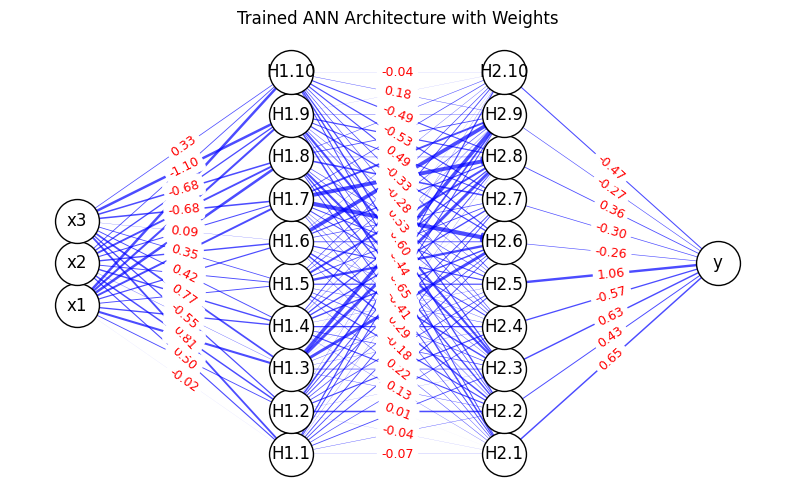

In [101]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def plot_nn(model, feature_names):
    G = nx.DiGraph()

    # Get weights from each layer
    weights = [layer.get_weights()[0] for layer in model.layers]
    biases = [layer.get_weights()[1] for layer in model.layers]

    # Layer sizes
    layers = [len(feature_names)] + [w.shape[1] for w in weights]  # e.g. [3,3,3,1]

    # Positions for nodes (layered horizontally)
    pos = {}
    horiz_gap = 2
    vert_gap = 1
    for i, layer_size in enumerate(layers):
        x = i * horiz_gap
        for j in range(layer_size):
            y = j - (layer_size - 1) / 2
            pos[(i,j)] = (x, y)
            G.add_node((i,j))

    # Add edges with weights as labels
    edge_labels = {}
    for i, W in enumerate(weights):
        for src in range(W.shape[0]):
            for tgt in range(W.shape[1]):
                weight = W[src, tgt]
                G.add_edge((i, src), (i+1, tgt), weight=weight)
                edge_labels[((i, src), (i+1, tgt))] = f"{weight:.2f}"

    # Draw nodes
    plt.figure(figsize=(10,6))
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='white', edgecolors='black')

    # Node labels: feature names for input, numbers for others
    labels = {}
    # input layer
    for i, name in enumerate(feature_names):
        labels[(0,i)] = name
    # hidden + output layers numbered
    for layer_idx in range(1, len(layers)):
        for neuron_idx in range(layers[layer_idx]):
            if layer_idx == len(layers)-1:
                labels[(layer_idx, neuron_idx)] = "y"
            else:
                labels[(layer_idx, neuron_idx)] = f"H{layer_idx}.{neuron_idx+1}"

    nx.draw_networkx_labels(G, pos, labels, font_size=12)

    # Draw edges
    edges = G.edges()
    weights_all = [abs(G[u][v]['weight']) for u,v in edges]
    # Normalize edge widths for visibility
    max_w = max(weights_all)
    widths = [3 * (w / max_w) for w in weights_all]
    nx.draw_networkx_edges(G, pos, edge_color='blue', width=widths, alpha=0.7)

    # Draw edge labels (weights)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)

    plt.axis('off')
    plt.title("Trained ANN Architecture with Weights")
    plt.show()

# Call function with your model and features
plot_nn(model, ['x1', 'x2', 'x3'])

In [95]:
# ANN(10, 10) predictions and MSE on the test set
from sklearn.metrics import mean_squared_error

y_pred_nn3 = model.predict(X_test).flatten()
mse_nn3 = mean_squared_error(y_test, y_pred_nn3)
print(f"ANN (2 hidden layers x 10 neurons) Test MSE: {mse_nn3:.6f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
ANN (2 hidden layers x 10 neurons) Test MSE: 0.000589


In [96]:
# Fit Linear Regression on Scaled Data

# Initialize and fit the Linear Regression model using the scaled training data
linreg_scaled = LinearRegression()
linreg_scaled.fit(X_train, y_train)

# Make predictions on the scaled test data
y_pred_lin_scaled = linreg_scaled.predict(X_test)

# Compute the Mean Squared Error (MSE) on the scaled test data
mse_lin_scaled = mean_squared_error(y_test, y_pred_lin_scaled)

print(f"Linear Regression on Scaled Data Test MSE: {mse_lin_scaled:.4f}")

Linear Regression on Scaled Data Test MSE: 0.0080


In [97]:
# Linear regression with 3-way interaction terms

def add_interactions(df):
    df_inter = df.copy()
    df_inter['x1_x2'] = df['x1'] * df['x2']
    df_inter['x1_x3'] = df['x1'] * df['x3']
    df_inter['x2_x3'] = df['x2'] * df['x3']
    df_inter['x1_x2_x3'] = df['x1'] * df['x2'] * df['x3']
    return df_inter

train_inter = add_interactions(train)
test_inter = add_interactions(test)

from sklearn.linear_model import LinearRegression

features = ['x1', 'x2', 'x3', 'x1_x2', 'x1_x3', 'x2_x3', 'x1_x2_x3']
linreg2 = LinearRegression()
linreg2.fit(train_inter[features], train_inter['y'])
y_pred_lin2 = linreg2.predict(test_inter[features])
mse_lin2 = mean_squared_error(test_inter['y'], y_pred_lin2)
print(f"Linear regression with interactions Test MSE: {mse_lin2:.6f}")

Linear regression with interactions Test MSE: 0.000082


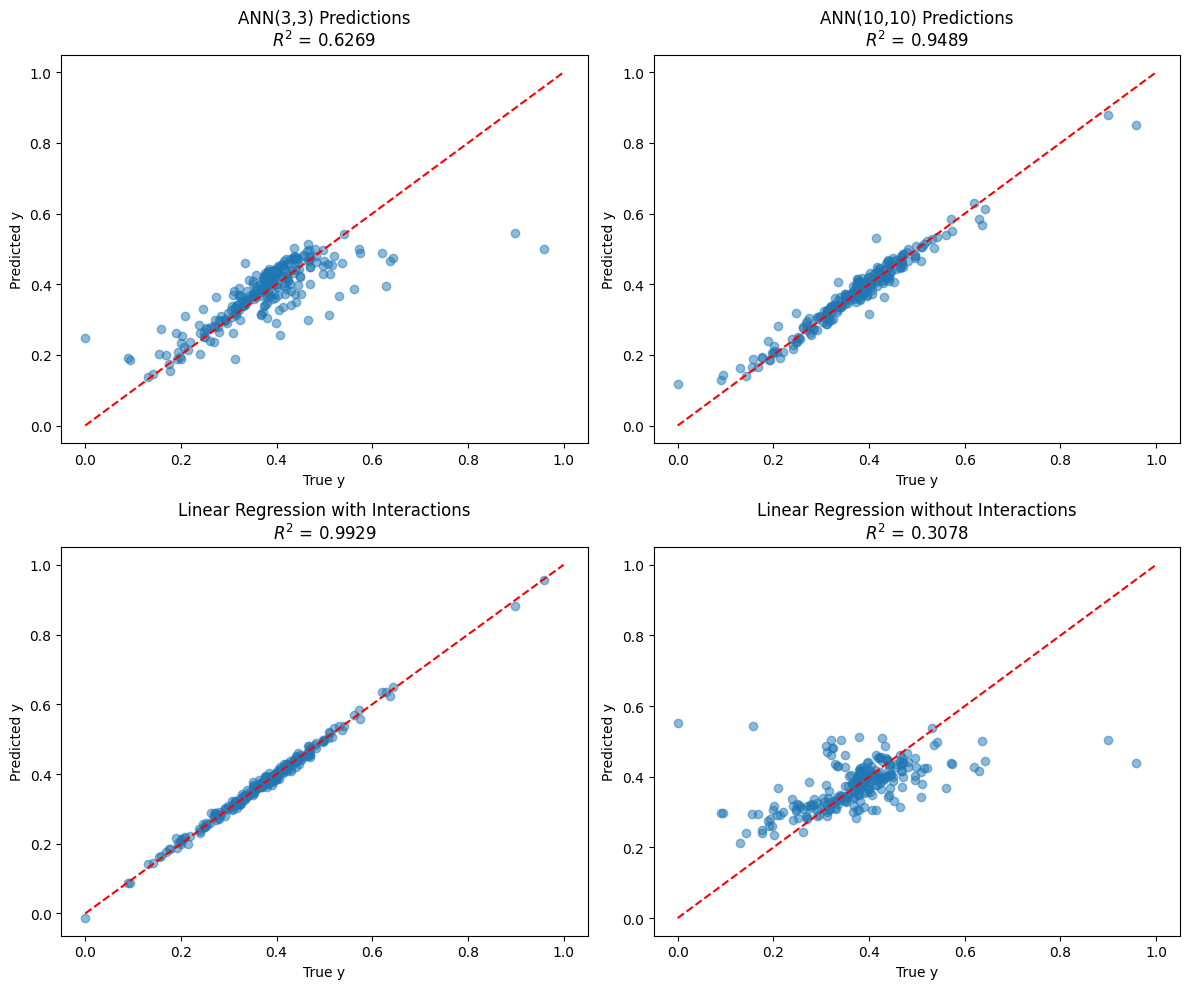

In [102]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Compute R² scores
r2_nn2 = r2_score(test['y'], y_pred_nn2)
r2_nn3 = r2_score(test['y'], y_pred_nn3)
r2_lin2 = r2_score(test['y'], y_pred_lin2)
r2_lin_scaled = r2_score(test['y'], y_pred_lin_scaled)

# Plot prediction comparison
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.scatter(test['y'], y_pred_nn2, alpha=0.5)
plt.title(f"ANN(3,3) Predictions\n$R^2$ = {r2_nn2:.4f}")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.plot([0,1],[0,1],'r--')

plt.subplot(2,2,2)
plt.scatter(test['y'], y_pred_nn3, alpha=0.5)
plt.title(f"ANN(10,10) Predictions\n$R^2$ = {r2_nn3:.4f}")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.plot([0,1],[0,1],'r--')

plt.subplot(2,2,3)
plt.scatter(test['y'], y_pred_lin2, alpha=0.5)
plt.title(f"Linear Regression with Interactions\n$R^2$ = {r2_lin2:.4f}")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.plot([0,1],[0,1],'r--')

plt.subplot(2,2,4)
plt.scatter(test['y'], y_pred_lin_scaled, alpha=0.5)
plt.title(f"Linear Regression without Interactions\n$R^2$ = {r2_lin_scaled:.4f}")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.plot([0,1],[0,1],'r--')

plt.tight_layout()
plt.show()


## Summary

We evaluated the performance of four different models in predicting the response variable from standardized features. The table below summarizes the Test Mean Squared Error (MSE) and is complemented by the prediction scatter plots:

| Model                                                | Test MSE     |
| ---------------------------------------------------- | ------------ |
| ANN (2 hidden layers × 3 neurons)                    | 0.004306     |
| ANN (2 hidden layers × 10 neurons)                   | 0.000589     |
| Linear Regression (no interactions)                  | 0.008000     |
| Linear Regression (with interactions) *(true model)* | **0.000082** |

Visual Comparison:

- The ANN(3,3) struggles to fully capture the nonlinear patterns, showing scattered residuals around the red diagonal.

- The ANN(10,10) improves dramatically, closely hugging the red line—indicating a much better fit to the complex nonlinearities.

- Linear regression without interactions fails to model the relationships, leading to larger and more systematic prediction errors.

- Linear regression with interactions performs the best, as it represents the true data-generating process (which includes interaction terms and nonlinearities by design).

Key Learning Points:

- Simple Linear Models Have Limits: Linear regression can only capture linear relationships. If nonlinearities or interactions are present in the data and not explicitly modeled, performance suffers significantly—as seen in the bottom right panel.

- Feature Engineering vs. Learning Nonlinearities: The "truth" model includes all interaction and polynomial terms, yielding the lowest MSE. However, manually adding such terms is not always feasible in real applications. Neural networks offer a flexible alternative.

- Model Complexity Matters: Increasing the number of neurons (from 3 to 10 per hidden layer) leads to a significantly better ANN fit. This shows how larger capacity allows ANNs to learn more complex patterns—but also highlights the need to tune model architecture carefully.

- Even Modest ANNs Can Learn Nonlinearities: The ANN(3,3) does improve over plain linear regression, indicating that even small neural networks can extract some nonlinear patterns from the data without manual interaction terms.

- Validation Is Essential: While the larger ANN performs better, we must still monitor for overfitting—especially when capacity increases. The inclusion of validation_split during training helps prevent this by monitoring out-of-sample performance.

- Prediction Plots Are Insightful: Visualizing predicted vs. actual values helps diagnose underfitting (scatter far from diagonal) or successful learning (tight clustering around diagonal).  